# Figure 3 main and supplementary figure generation

This notebook creates **Figure 3 main** and **Supplementary Figure S3** from the precomputed Figure 3 calculation results.

It is designed to be run from:

`differential_analysis/code/`

Expected project structure:

```text
differential_analysis/
├── code/
├── data/
├── cox/
├── result/
│   └── figure3_calculation/
└── figure/
```

Outputs are saved to:

`differential_analysis/figure/`

This revised version fixes:
- volcano plot labels with no long spike/connector lines
- CoxPH calculation directly from `cox/` when CoxPH result CSV is missing
- supplementary figure now uses only panels a–d, no e panel

In [1]:
# ============================================================
# 1. Imports and global settings
# ============================================================

from pathlib import Path
import os
import re
import math
import warnings
import subprocess
import sys

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

# ----------------------------
# Figure style
# ----------------------------
MM_TO_INCH = 1 / 25.4
FIG_WIDTH_MM = 170
FIG_WIDTH_IN = FIG_WIDTH_MM * MM_TO_INCH
DPI = 600

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
})

# If Arial is unavailable, matplotlib will fall back automatically.

In [2]:
# ============================================================
# 2. Path setup
# ============================================================

NOTEBOOK_DIR = Path.cwd()

# Expected: .../differential_analysis/code
if NOTEBOOK_DIR.name.lower() == "code":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    # Allows running from the project root as well
    PROJECT_DIR = NOTEBOOK_DIR

DATA_DIR = PROJECT_DIR / "data"
COX_DIR = PROJECT_DIR / "cox"
RESULT_DIR = PROJECT_DIR / "result" / "figure3_calculation"
FIGURE_DIR = PROJECT_DIR / "figure"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:   ", DATA_DIR)
print("Cox directory:    ", COX_DIR)
print("Result directory: ", RESULT_DIR)
print("Figure directory: ", FIGURE_DIR)

Project directory: c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis
Data directory:    c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\data
Cox directory:     c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\cox
Result directory:  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\result\figure3_calculation
Figure directory:  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure


In [3]:
# ============================================================
# 3. Helper functions
# ============================================================

def read_csv_if_exists(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return None


def find_first_existing(directory, candidates):
    directory = Path(directory)
    for name in candidates:
        p = directory / name
        if p.exists():
            return p
    return None


def normalize_feature_name(name):
    """Make feature labels human-readable but keep enough detail."""
    if pd.isna(name):
        return ""
    s = str(name)
    s = s.replace("static_", "")
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def canonical_name(name):
    """Canonical form for matching feature names across files."""
    if pd.isna(name):
        return ""
    s = str(name).lower().strip()
    s = s.replace("static_", "")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s


def find_col(df, candidates):
    """Find a column by case/spacing-insensitive matching."""
    if df is None or df.empty:
        return None
    canon_to_col = {canonical_name(c): c for c in df.columns}
    for cand in candidates:
        key = canonical_name(cand)
        if key in canon_to_col:
            return canon_to_col[key]
    return None


def get_numeric_feature_cols(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = set()
    else:
        exclude_cols = set(exclude_cols)
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def save_figure(fig, base_name):
    png = FIGURE_DIR / f"{base_name}.png"
    pdf = FIGURE_DIR / f"{base_name}.pdf"
    svg = FIGURE_DIR / f"{base_name}.svg"

    fig.savefig(png, dpi=DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    fig.savefig(svg, bbox_inches="tight", facecolor="white")

    print("Saved:")
    print(" ", png)
    print(" ", pdf)
    print(" ", svg)

    return {"png": png, "pdf": pdf, "svg": svg}


def add_panel_label(ax, label, x=-0.12, y=1.04):
    # Only the panel label itself is bold.
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontweight="bold",
        fontsize=8,
        clip_on=False,
    )


def clean_axes(ax, grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid:
        ax.grid(True, color="#e6e6e6", linewidth=0.5)
        ax.set_axisbelow(True)


def domain_for_feature(feature):
    s = str(feature).lower()

    neurological = ["gcs"]
    renal = ["bun", "creatinine", "urine", "urea"]
    cardiovascular = ["hr", "heart", "map", "sysabp", "diasabp", "nibp", "troponin"]
    respiratory = ["pao2", "fio2", "sao2", "spo2", "mechvent", "resp", "ph", "paco2"]
    metabolic = ["lactate", "hco3", "glucose", "k", "na", "mg", "calcium", "temp", "ph"]
    hematologic = ["wbc", "platelets", "hct", "hgb", "bilirubin", "albumin"]
    missingness = ["missing", "count", "measured"]

    if any(k in s for k in neurological):
        return "Neurological"
    if any(k in s for k in renal):
        return "Renal"
    if any(k in s for k in cardiovascular):
        return "Cardiovascular"
    if any(k in s for k in respiratory):
        return "Respiratory"
    if any(k in s for k in metabolic):
        return "Metabolic"
    if any(k in s for k in hematologic):
        return "Hematologic"
    if any(k in s for k in missingness):
        return "Measurement / missingness"
    if "age" in s or "gender" in s or "sex" in s or "icu" in s or "height" in s or "weight" in s:
        return "Static / demographic"
    return "Other"


DOMAIN_COLORS = {
    "Neurological": "#4C78A8",
    "Renal": "#72B7B2",
    "Metabolic": "#F58518",
    "Respiratory": "#54A24B",
    "Cardiovascular": "#E45756",
    "Hematologic": "#B279A2",
    "Static / demographic": "#9D755D",
    "Measurement / missingness": "#8C8C8C",
    "Other": "#BDBDBD",
}

HIGH_DEATH_COLOR = "#D65F3A"
HIGH_SURV_COLOR = "#3B7BA8"
NOT_SELECTED_COLOR = "#D9DEE2"
MATRIX_COLOR = "#0E7C72"
MATRIX_LIGHT = "#F0F0F0"

In [4]:
# ============================================================
# 4. Load precomputed result CSVs
# ============================================================

diff_results_path = RESULT_DIR / "differential_analysis_results_training_only.csv"
selected_path = RESULT_DIR / "differential_selected_features_training_only.csv"
validation_path = RESULT_DIR / "differential_train_test_validation.csv"
support_path = RESULT_DIR / "figure3_evidence_support_matrix.csv"
support_top20_path = RESULT_DIR / "figure3_evidence_support_matrix_top20.csv"
summary_path = RESULT_DIR / "figure3_calculation_summary.csv"
cox_results_path = RESULT_DIR / "coxph_univariate_results.csv"

diff_results = read_csv_if_exists(diff_results_path)
selected_features = read_csv_if_exists(selected_path)
validation = read_csv_if_exists(validation_path)
support_matrix = read_csv_if_exists(support_path)
support_top20 = read_csv_if_exists(support_top20_path)
summary_df = read_csv_if_exists(summary_path)
cox_results = read_csv_if_exists(cox_results_path)

required_files = {
    "differential_analysis_results_training_only.csv": diff_results,
    "differential_selected_features_training_only.csv": selected_features,
}

missing = [name for name, df in required_files.items() if df is None]
if missing:
    raise FileNotFoundError(
        "Missing required result files in result/figure3_calculation/:\n"
        + "\n".join(missing)
        + "\nRun the Figure 3 calculation notebook first."
    )

print("Loaded:")
for name, df in [
    ("diff_results", diff_results),
    ("selected_features", selected_features),
    ("validation", validation),
    ("support_matrix", support_matrix),
    ("summary_df", summary_df),
    ("cox_results", cox_results),
]:
    print(f"  {name:16s}", None if df is None else df.shape)

print("\nDifferential result columns:")
print(diff_results.columns.tolist())

if cox_results is not None:
    print("\nExisting CoxPH result columns:")
    print(cox_results.columns.tolist())

Loaded:
  diff_results     (243, 16)
  selected_features (91, 16)
  validation       (243, 10)
  support_matrix   (12, 26)
  summary_df       (17, 2)
  cox_results      (12, 12)

Differential result columns:
['feature', 'clinical_domain', 'split', 'n_survivors', 'n_deaths', 'survivor_mean', 'death_mean', 'survivor_median', 'death_median', 'smd_death_minus_survivor', 't_stat', 'p_value', 'fdr_bh', 'abs_smd', 'direction', 'differential_supported']

Existing CoxPH result columns:
['feature', 'feature_label', 'domain', 'hazard_ratio', 'ci_lower', 'ci_upper', 'p_value', 'n', 'events', 'backend', 'fdr', 'coxph_supported']


In [5]:
# ============================================================
# 5. Standardize differential result column names
# ============================================================

# IMPORTANT:
# If your notebook still shows the short candidate list
# ["smd", "standardized_mean_difference", "effect_size", "train_smd"],
# you are running an older cell. This version explicitly supports the output
# from 01_compute_figure3_results_only_v6_with_cox_folder.ipynb:
#   smd_death_minus_survivor, fdr_bh, clinical_domain, differential_supported


def standardize_diff_df(df):
    df = df.copy()

    print("Differential result columns detected:")
    print(df.columns.tolist())

    col_feature = find_col(df, [
        "feature", "variable", "Feature", "feature_name", "name"
    ])
    col_smd = find_col(df, [
        "smd", "SMD", "standardized_mean_difference", "standardised_mean_difference",
        "effect_size", "train_smd", "test_smd", "smd_death_minus_survivor",
        "death_minus_survivor_smd", "smd_nonsurvivor_minus_survivor",
        "standardized_effect_size", "cohens_d", "cohen_d", "mean_difference_standardized"
    ])
    col_abs_smd = find_col(df, [
        "abs_smd", "absolute_smd", "abs_standardized_mean_difference"
    ])
    col_fdr = find_col(df, [
        "fdr", "FDR", "fdr_bh", "bh_fdr", "adj_p_value", "adj_pval", "adjusted_p_value",
        "q_value", "welch_fdr", "padj", "fdr_corrected_p_value"
    ])
    col_p = find_col(df, [
        "p_value", "pvalue", "p_val", "welch_p_value", "p"
    ])
    col_domain = find_col(df, [
        "domain", "clinical_domain", "feature_domain"
    ])
    col_selected = find_col(df, [
        "selected", "differential_supported", "is_selected", "significant"
    ])
    col_direction = find_col(df, [
        "direction", "effect_direction", "smd_direction"
    ])

    if col_feature is None:
        raise ValueError(
            "Could not identify feature column. Available columns were:\n" +
            "\n".join(df.columns.astype(str))
        )
    if col_fdr is None:
        raise ValueError(
            "Could not identify FDR/adjusted p-value column. Available columns were:\n" +
            "\n".join(df.columns.astype(str))
        )

    out = df.copy()
    rename_map = {col_feature: "feature", col_fdr: "fdr"}
    if col_smd is not None:
        rename_map[col_smd] = "smd"
    if col_p is not None:
        rename_map[col_p] = "p_value"
    out = out.rename(columns=rename_map)

    # Fallback: some files may only have abs_smd + direction.
    if "smd" not in out.columns:
        if col_abs_smd is not None and col_direction is not None:
            tmp_abs = pd.to_numeric(out[col_abs_smd], errors="coerce")
            tmp_dir = out[col_direction].astype(str).str.lower()
            sign = np.where(tmp_dir.str.contains("death|non-survivor|nonsurvivor|positive|higher_in_deaths"), 1, -1)
            out["smd"] = tmp_abs * sign
            print("Reconstructed signed SMD from abs_smd + direction.")
        else:
            raise ValueError(
                "Could not identify SMD/effect-size column. Available columns were:\n" +
                "\n".join(df.columns.astype(str))
            )

    if "p_value" not in out.columns:
        out["p_value"] = np.nan

    out["feature"] = out["feature"].astype(str)
    out["feature_label"] = out["feature"].map(normalize_feature_name)
    if col_domain is not None:
        out["domain"] = out[col_domain].fillna(out["feature"].map(domain_for_feature))
    else:
        out["domain"] = out["feature"].map(domain_for_feature)

    out["fdr"] = pd.to_numeric(out["fdr"], errors="coerce")
    out["smd"] = pd.to_numeric(out["smd"], errors="coerce")
    out["minus_log10_fdr"] = -np.log10(out["fdr"].clip(lower=1e-300))

    if col_selected is not None:
        selected_raw = out[col_selected]
        if selected_raw.dtype == bool:
            out["selected"] = selected_raw
        else:
            out["selected"] = selected_raw.astype(str).str.lower().isin(["true", "1", "yes", "y", "selected"])
    else:
        out["selected"] = (out["fdr"] < 0.05) & (out["smd"].abs() > 0.20)

    out["direction"] = np.where(out["smd"] > 0, "Higher in deaths", "Higher in survivors")
    out.loc[~out["selected"], "direction"] = "Not selected"

    return out


diff_std = standardize_diff_df(diff_results)
selected_std = diff_std.loc[diff_std["selected"]].copy()

print("Features tested:", len(diff_std))
print("Selected features:", len(selected_std))
print(selected_std.sort_values("fdr").head(10)[["feature", "smd", "fdr", "domain"]])


Differential result columns detected:
['feature', 'clinical_domain', 'split', 'n_survivors', 'n_deaths', 'survivor_mean', 'death_mean', 'survivor_median', 'death_median', 'smd_death_minus_survivor', 't_stat', 'p_value', 'fdr_bh', 'abs_smd', 'direction', 'differential_supported']
Features tested: 243
Selected features: 91
               feature       smd            fdr                     domain
0             GCS_last -0.958434  6.132619e-128               Neurological
1           GCS_median -0.780115   1.465943e-93               Neurological
2             GCS_mean -0.737663   3.338369e-84               Neurological
3              GCS_max -0.707754   2.460690e-70               Neurological
4             BUN_last  0.618343   6.153992e-59                      Renal
5             BUN_mean  0.570449   1.133465e-51                      Renal
6              BUN_min  0.572716   3.267639e-51                      Renal
7           BUN_median  0.563152   9.624145e-51                      Renal
8 

In [6]:
# ============================================================
# 6. CoxPH helper: compute CoxPH directly from cox/ folder if needed
# ============================================================

def load_x_train_and_y_train():
    x_path = find_first_existing(DATA_DIR, [
        "X_train.csv", "X_train_clean.csv", "X_train_ml_ready.csv",
        "X_train(13).csv", "X_train(4).csv"
    ])
    y_path = find_first_existing(DATA_DIR, [
        "y_train.csv", "y_train_clean.csv", "y_train_ml_ready.csv",
        "time_series_y_train_a_plus_b_train_c_test.csv",
        "time_series_y_train_a_plus_b_train_c_test(6).csv",
        "time_series_y_train_a_plus_b_train_c_test(5).csv",
        "train_outcomes.csv", "outcomes_train.csv"
    ])

    X = pd.read_csv(x_path) if x_path is not None else None
    y = pd.read_csv(y_path) if y_path is not None else None

    print("X_train path:", x_path)
    print("y_train path:", y_path)
    if X is not None:
        print("X_train shape:", X.shape)
    if y is not None:
        print("y_train shape:", y.shape)

    return X, y


def build_cox_model_input_from_folders(candidate_features):
    """
    Build model input for CoxPH by merging X_train with cox/ outcome files.

    Preferred matching:
    1. RecordID in X_train
    2. RecordID in y_train aligned to X_train row order
    3. cox_outcome_all_rows_with_qc.csv first len(X_train) rows aligned to X_train row order
    4. direct row-order only if lengths match
    """

    X_train, y_train = load_x_train_and_y_train()

    if X_train is None:
        print("Cannot compute CoxPH because X_train.csv was not found.")
        return None

    cox_valid_path = find_first_existing(COX_DIR, [
        "cox_input_train_ab_valid_rows.csv",
        "cox_input_valid_rows.csv",
    ])
    cox_all_path = find_first_existing(COX_DIR, [
        "cox_outcome_all_rows_with_qc.csv",
    ])

    if cox_valid_path is None and cox_all_path is None:
        print("Cannot compute CoxPH because no cox input files were found in cox/.")
        return None

    cox_valid = pd.read_csv(cox_valid_path) if cox_valid_path is not None else None
    cox_all = pd.read_csv(cox_all_path) if cox_all_path is not None else None

    print("cox_valid path:", cox_valid_path)
    print("cox_all path:  ", cox_all_path)
    if cox_valid is not None:
        print("cox_valid shape:", cox_valid.shape)
    if cox_all is not None:
        print("cox_all shape:", cox_all.shape)

    # Standardize cox time/event if possible.
    def prepare_cox_df(cox_df):
        cox_df = cox_df.copy()

        event_col = find_col(cox_df, ["cox_event", "event", "in_hospital_death", "In-hospital_death", "in_hospital_mortality"])
        time_col = find_col(cox_df, ["cox_time_days", "cox_time", "time", "duration"])

        if event_col is None:
            raise ValueError("No event column found in Cox input.")

        if time_col is None:
            los_col = find_col(cox_df, ["Length_of_stay", "length_of_stay", "LOS"])
            surv_col = find_col(cox_df, ["Survival", "survival"])
            if los_col is None or surv_col is None:
                raise ValueError("No time column found and could not derive from Survival/Length_of_stay.")

            event = pd.to_numeric(cox_df[event_col], errors="coerce")
            los = pd.to_numeric(cox_df[los_col], errors="coerce")
            surv = pd.to_numeric(cox_df[surv_col], errors="coerce")
            cox_df["cox_time_days"] = np.where(event == 1, surv, los)
            cox_df["cox_event"] = event
        else:
            cox_df["cox_time_days"] = pd.to_numeric(cox_df[time_col], errors="coerce")
            cox_df["cox_event"] = pd.to_numeric(cox_df[event_col], errors="coerce")

        cox_df["cox_valid"] = (
            cox_df["cox_time_days"].notna()
            & (cox_df["cox_time_days"] > 0)
            & cox_df["cox_event"].isin([0, 1])
        )

        return cox_df

    cox_valid_prepped = prepare_cox_df(cox_valid) if cox_valid is not None else None
    cox_all_prepped = prepare_cox_df(cox_all) if cox_all is not None else None

    rid_x = find_col(X_train, ["RecordID", "record_id", "patient_id", "id"])
    rid_y = find_col(y_train, ["RecordID", "record_id", "patient_id", "id"]) if y_train is not None else None
    rid_cox_valid = find_col(cox_valid_prepped, ["RecordID", "record_id", "patient_id", "id"]) if cox_valid_prepped is not None else None
    rid_cox_all = find_col(cox_all_prepped, ["RecordID", "record_id", "patient_id", "id"]) if cox_all_prepped is not None else None

    # Match feature column names in X_train.
    x_cols_by_canon = {canonical_name(c): c for c in X_train.columns}
    candidate_x_cols = []
    for f in candidate_features:
        key = canonical_name(f)
        if key in x_cols_by_canon:
            candidate_x_cols.append(x_cols_by_canon[key])

    # If not enough exact candidate features, include top differential selected features present in X_train.
    if len(candidate_x_cols) < 5:
        for f in selected_std.sort_values(["fdr", "smd"], ascending=[True, False])["feature"].tolist():
            key = canonical_name(f)
            if key in x_cols_by_canon and x_cols_by_canon[key] not in candidate_x_cols:
                candidate_x_cols.append(x_cols_by_canon[key])
            if len(candidate_x_cols) >= 30:
                break

    # Remove clearly problematic columns
    candidate_x_cols = [
        c for c in candidate_x_cols
        if c in X_train.columns
        and pd.api.types.is_numeric_dtype(X_train[c])
        and canonical_name(c) not in {canonical_name(x) for x in ["RecordID", "in_hospital_death", "SAPS-I", "SOFA", "Length_of_stay", "Survival"]}
    ]

    if len(candidate_x_cols) == 0:
        print("No candidate CoxPH feature columns were found in X_train.")
        return None

    print("Candidate CoxPH features found in X_train:", len(candidate_x_cols))
    print(candidate_x_cols[:20])

    # Build merged input
    if rid_x is not None and cox_valid_prepped is not None and rid_cox_valid is not None:
        X_tmp = X_train[[rid_x] + candidate_x_cols].copy()
        cox_tmp = cox_valid_prepped[[rid_cox_valid, "cox_time_days", "cox_event", "cox_valid"]].copy()
        model_df = X_tmp.merge(cox_tmp, left_on=rid_x, right_on=rid_cox_valid, how="inner")

    elif rid_y is not None and cox_valid_prepped is not None and rid_cox_valid is not None:
        X_tmp = X_train[candidate_x_cols].copy()
        X_tmp[rid_y] = y_train[rid_y].values
        cox_tmp = cox_valid_prepped[[rid_cox_valid, "cox_time_days", "cox_event", "cox_valid"]].copy()
        model_df = X_tmp.merge(cox_tmp, left_on=rid_y, right_on=rid_cox_valid, how="inner")

    elif cox_all_prepped is not None and len(cox_all_prepped) >= len(X_train):
        # Assume A+B are first len(X_train) rows. This matches the prepared A+B train / C test split.
        cox_train_full = cox_all_prepped.iloc[:len(X_train)].reset_index(drop=True)
        X_tmp = X_train[candidate_x_cols].reset_index(drop=True)
        model_df = pd.concat(
            [X_tmp, cox_train_full[["cox_time_days", "cox_event", "cox_valid"]].reset_index(drop=True)],
            axis=1
        )
        model_df = model_df.loc[model_df["cox_valid"]].copy()

    elif cox_valid_prepped is not None and len(cox_valid_prepped) == len(X_train):
        X_tmp = X_train[candidate_x_cols].reset_index(drop=True)
        model_df = pd.concat(
            [X_tmp, cox_valid_prepped[["cox_time_days", "cox_event", "cox_valid"]].reset_index(drop=True)],
            axis=1
        )
        model_df = model_df.loc[model_df["cox_valid"]].copy()

    else:
        print("Could not align X_train with CoxPH outcome rows safely.")
        print("X_train rows:", len(X_train))
        if cox_valid_prepped is not None:
            print("cox valid rows:", len(cox_valid_prepped))
        if cox_all_prepped is not None:
            print("cox all rows:", len(cox_all_prepped))
        return None

    model_df = model_df.replace([np.inf, -np.inf], np.nan)
    model_df = model_df.dropna(subset=["cox_time_days", "cox_event"])

    # Keep only model features + time/event
    keep_cols = ["cox_time_days", "cox_event"] + [c for c in candidate_x_cols if c in model_df.columns]
    model_df = model_df[keep_cols].copy()

    # Median impute feature columns for CoxPH
    for c in candidate_x_cols:
        if c in model_df.columns:
            model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
            if model_df[c].notna().sum() > 0:
                model_df[c] = model_df[c].fillna(model_df[c].median())

    print("CoxPH model input shape:", model_df.shape)
    print("CoxPH events:", int(model_df["cox_event"].sum()))

    out_path = RESULT_DIR / "coxph_model_input_train_ab_from_figure_notebook.csv"
    model_df.to_csv(out_path, index=False)
    print("Saved CoxPH model input:", out_path)

    return model_df


def compute_univariate_coxph(model_df, feature_cols):
    """Compute univariate CoxPH with lifelines or statsmodels fallback."""
    if model_df is None or model_df.empty:
        return pd.DataFrame()

    results = []

    # Try lifelines
    try:
        from lifelines import CoxPHFitter
        backend = "lifelines"
    except Exception:
        CoxPHFitter = None
        backend = None

    # Try statsmodels fallback
    if backend is None:
        try:
            from statsmodels.duration.hazard_regression import PHReg
            backend = "statsmodels"
        except Exception:
            PHReg = None
            backend = None

    if backend is None:
        print("No CoxPH backend available. Install lifelines or statsmodels to compute CoxPH.")
        return pd.DataFrame()

    print("CoxPH backend:", backend)

    for feat in feature_cols:
        if feat not in model_df.columns:
            continue

        tmp = model_df[["cox_time_days", "cox_event", feat]].copy()
        tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

        if tmp.shape[0] < 50:
            continue
        if tmp["cox_event"].sum() < 10:
            continue
        if tmp[feat].nunique(dropna=True) < 2:
            continue

        # Standardize feature for stable HR per 1 SD.
        sd = tmp[feat].std()
        if not np.isfinite(sd) or sd == 0:
            continue
        tmp[feat + "_z"] = (tmp[feat] - tmp[feat].mean()) / sd

        try:
            if backend == "lifelines":
                fit_df = tmp[["cox_time_days", "cox_event", feat + "_z"]].copy()
                cph = CoxPHFitter(penalizer=0.01)
                cph.fit(fit_df, duration_col="cox_time_days", event_col="cox_event")
                row = cph.summary.loc[feat + "_z"]
                hr = float(np.exp(row["coef"]))
                ci_lower = float(np.exp(row["coef lower 95%"]))
                ci_upper = float(np.exp(row["coef upper 95%"]))
                p_value = float(row["p"])

            else:
                fit_df = tmp[["cox_time_days", "cox_event", feat + "_z"]].copy()
                mod = PHReg(
                    endog=fit_df["cox_time_days"].astype(float),
                    exog=fit_df[[feat + "_z"]].astype(float),
                    status=fit_df["cox_event"].astype(int),
                )
                res = mod.fit(disp=False)
                coef = float(res.params[0])
                se = float(res.bse[0])
                hr = float(np.exp(coef))
                ci_lower = float(np.exp(coef - 1.96 * se))
                ci_upper = float(np.exp(coef + 1.96 * se))
                p_value = float(res.pvalues[0])

            results.append({
                "feature": feat,
                "feature_label": normalize_feature_name(feat),
                "domain": domain_for_feature(feat),
                "hazard_ratio": hr,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "p_value": p_value,
                "n": int(tmp.shape[0]),
                "events": int(tmp["cox_event"].sum()),
                "backend": backend,
            })

        except Exception as e:
            results.append({
                "feature": feat,
                "feature_label": normalize_feature_name(feat),
                "domain": domain_for_feature(feat),
                "hazard_ratio": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
                "p_value": np.nan,
                "n": int(tmp.shape[0]),
                "events": int(tmp["cox_event"].sum()),
                "backend": backend,
                "error": str(e)[:200],
            })

    out = pd.DataFrame(results)

    if out.empty:
        return out

    valid = out["p_value"].notna()
    out["fdr"] = np.nan
    if valid.sum() > 0:
        out.loc[valid, "fdr"] = multipletests(out.loc[valid, "p_value"], method="fdr_bh")[1]

    out["coxph_supported"] = (
        out["hazard_ratio"].notna()
        & out["fdr"].notna()
        & (out["fdr"] < 0.05)
        & ((out["ci_lower"] > 1) | (out["ci_upper"] < 1))
    )

    out = out.sort_values(["fdr", "p_value"], na_position="last").reset_index(drop=True)

    return out

In [7]:
# ============================================================
# 7. Prepare support matrix and CoxPH result
# ============================================================

# Preferred features for the support matrix.
if support_matrix is not None and not support_matrix.empty:
    support_work = support_matrix.copy()
elif support_top20 is not None and not support_top20.empty:
    support_work = support_top20.copy()
else:
    # Fallback from ML shared features file in data/
    shared_path = DATA_DIR / "top30_shared_features_by_pair.csv"
    if shared_path.exists():
        support_work = pd.read_csv(shared_path)
    else:
        support_work = pd.DataFrame()

print("Initial support_work shape:", support_work.shape)
print("Initial support_work columns:", support_work.columns.tolist() if not support_work.empty else [])

# Standardize support matrix feature column.
if not support_work.empty:
    feature_col = find_col(support_work, ["feature", "Feature"])
    if feature_col is None:
        # Some overlap files may use another name; pick first non-rank text col.
        for c in support_work.columns:
            if support_work[c].dtype == "object":
                feature_col = c
                break
    if feature_col is None:
        raise ValueError("Could not find feature column in support matrix.")
    support_work = support_work.rename(columns={feature_col: "feature"})
else:
    # Fallback: top selected differential features.
    support_work = selected_std.sort_values("fdr").head(12)[["feature"]].copy()

support_work["feature_label"] = support_work["feature"].map(normalize_feature_name)
support_work["domain"] = support_work["feature"].map(domain_for_feature)
support_work["canon"] = support_work["feature"].map(canonical_name)

# Keep top 12 shared/important features for main panel c.
if len(support_work) > 12:
    # If mean_rank exists, use it. Otherwise preserve order.
    mean_rank_col = find_col(support_work, ["mean_rank", "rank", "rank_a"])
    if mean_rank_col is not None:
        support_work = support_work.sort_values(mean_rank_col).head(12).copy()
    else:
        support_work = support_work.head(12).copy()

candidate_features = support_work["feature"].dropna().astype(str).tolist()
print("Main support features:", candidate_features)

# If CoxPH result is missing or empty, compute from cox/ folder.
cox_needed = cox_results is None or cox_results.empty
if not cox_needed:
    hr_col = find_col(cox_results, ["hazard_ratio", "hr"])
    if hr_col is None or cox_results[hr_col].notna().sum() == 0:
        cox_needed = True

if cox_needed:
    print("\nNo usable CoxPH results found in result/. Computing CoxPH from cox/ folder...")
    cox_model_input = build_cox_model_input_from_folders(candidate_features)

    if cox_model_input is not None:
        # Use support features plus selected differential features for extended CoxPH.
        feature_cols = [c for c in cox_model_input.columns if c not in ["cox_time_days", "cox_event"]]
        cox_results = compute_univariate_coxph(cox_model_input, feature_cols)

        if cox_results is not None and not cox_results.empty:
            cox_results.to_csv(cox_results_path, index=False)
            print("Saved CoxPH results:", cox_results_path)
    else:
        cox_results = pd.DataFrame()
else:
    print("\nUsing existing CoxPH result file:", cox_results_path)

print("\nCoxPH result shape:", None if cox_results is None else cox_results.shape)
if cox_results is not None and not cox_results.empty:
    print(cox_results.head(10))

Initial support_work shape: (12, 26)
Initial support_work columns: ['model_a', 'model_b', 'feature', 'rank_a', 'rank_b', 'mean_rank', 'ml_shared_top30', 'rank_logistic_regression', 'rank_xgboost_auc_optimized', 'clinical_domain', 'train_smd', 'train_fdr', 'train_abs_smd', 'train_differential_supported', 'test_smd', 'test_fdr', 'test_abs_smd', 'same_effect_direction', 'cox_hr', 'cox_ci_lower', 'cox_ci_upper', 'cox_p_value', 'cox_fdr', 'coxph_supported', 'heldout_same_direction', 'n_support_sources']
Main support features: ['GCS_last', 'BUN_last', 'static_Age', 'Lactate_last', 'Urine_mean', 'GCS_mean', 'Urine_total', 'Creatinine_median', 'PaO2_median', 'HR_mean', 'GCS_std', 'Temp_median']

Using existing CoxPH result file: c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\result\figure3_calculation\coxph_univariate_results.csv

CoxPH result shape: (12, 12)
             feature      feature_label                domain  hazard_ratio  \
0           GCS_last           GCS la

In [8]:
# ============================================================
# 8. Standardize CoxPH results and update support matrix
# ============================================================

def standardize_cox_df(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=[
            "feature", "feature_label", "domain",
            "hazard_ratio", "ci_lower", "ci_upper", "p_value", "fdr", "coxph_supported", "canon"
        ])

    df = df.copy()
    col_feature = find_col(df, ["feature", "variable", "Feature"])
    col_hr = find_col(df, ["hazard_ratio", "hr", "exp_coef"])
    col_low = find_col(df, ["ci_lower", "lower_95", "hr_ci_lower", "lower"])
    col_high = find_col(df, ["ci_upper", "upper_95", "hr_ci_upper", "upper"])
    col_p = find_col(df, ["p_value", "p", "pval"])
    col_fdr = find_col(df, ["fdr", "fdr_bh", "bh_fdr", "adj_p_value", "adj_pval", "adjusted_p_value", "q_value", "padj"])
    col_supported = find_col(df, ["coxph_supported", "supported"])

    rename = {}
    if col_feature: rename[col_feature] = "feature"
    if col_hr: rename[col_hr] = "hazard_ratio"
    if col_low: rename[col_low] = "ci_lower"
    if col_high: rename[col_high] = "ci_upper"
    if col_p: rename[col_p] = "p_value"
    if col_fdr: rename[col_fdr] = "fdr"
    if col_supported: rename[col_supported] = "coxph_supported"

    df = df.rename(columns=rename)

    if "feature" not in df:
        return pd.DataFrame()

    for c in ["hazard_ratio", "ci_lower", "ci_upper", "p_value", "fdr"]:
        if c not in df:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "fdr" not in df or df["fdr"].notna().sum() == 0:
        valid = df["p_value"].notna()
        df["fdr"] = np.nan
        if valid.sum() > 0:
            df.loc[valid, "fdr"] = multipletests(df.loc[valid, "p_value"], method="fdr_bh")[1]

    if "coxph_supported" not in df:
        df["coxph_supported"] = (
            df["hazard_ratio"].notna()
            & df["fdr"].notna()
            & (df["fdr"] < 0.05)
            & ((df["ci_lower"] > 1) | (df["ci_upper"] < 1))
        )
    else:
        df["coxph_supported"] = df["coxph_supported"].astype(str).str.lower().isin(["true", "1", "yes"])

    df["feature_label"] = df["feature"].map(normalize_feature_name)
    df["domain"] = df["feature"].map(domain_for_feature)
    df["canon"] = df["feature"].map(canonical_name)

    return df

cox_std = standardize_cox_df(cox_results)
print("Standardized CoxPH:", cox_std.shape)
if not cox_std.empty:
    print(cox_std.head(10)[["feature", "hazard_ratio", "ci_lower", "ci_upper", "fdr", "coxph_supported"]])

# Add differential support and validation support to matrix.
diff_lookup = diff_std.set_index("feature")
diff_lookup_canon = diff_std.assign(canon=diff_std["feature"].map(canonical_name)).set_index("canon")

val_std = validation.copy() if validation is not None else pd.DataFrame()
if not val_std.empty:
    val_feat_col = find_col(val_std, ["feature", "Feature"])
    train_smd_col = find_col(val_std, ["train_smd", "training_smd", "smd_train"])
    test_smd_col = find_col(val_std, ["test_smd", "held_out_smd", "smd_test"])
    same_col = find_col(val_std, ["same_direction", "same_effect_direction", "direction_consistent", "heldout_same_direction", "held_out_same_direction"])

    if val_feat_col:
        val_std = val_std.rename(columns={val_feat_col: "feature"})
    if train_smd_col:
        val_std = val_std.rename(columns={train_smd_col: "train_smd"})
    if test_smd_col:
        val_std = val_std.rename(columns={test_smd_col: "test_smd"})
    if same_col:
        val_std = val_std.rename(columns={same_col: "same_direction"})
    elif {"train_smd", "test_smd"}.issubset(val_std.columns):
        val_std["same_direction"] = np.sign(val_std["train_smd"]) == np.sign(val_std["test_smd"])

    if "feature" in val_std.columns:
        val_std["canon"] = val_std["feature"].map(canonical_name)
        val_lookup = val_std.set_index("canon")
    else:
        val_lookup = pd.DataFrame()
else:
    val_lookup = pd.DataFrame()

cox_lookup = cox_std.set_index("canon") if not cox_std.empty else pd.DataFrame()

# Standardize rank columns if present.
lr_rank_col = find_col(support_work, ["logistic_rank", "lr_rank", "rank_a"])
xgb_rank_col = find_col(support_work, ["xgboost_rank", "xgb_rank", "rank_b"])

# If rankings are in long format, pull them from data.
rank_long_path = DATA_DIR / "top30_feature_rankings_long.csv"
rank_long = pd.read_csv(rank_long_path) if rank_long_path.exists() else pd.DataFrame()

rank_map = {}
if not rank_long.empty:
    fcol = find_col(rank_long, ["feature"])
    mcol = find_col(rank_long, ["model", "model_name"])
    rcol = find_col(rank_long, ["rank", "rank_a", "rank_b"])
    if fcol and mcol and rcol:
        tmp = rank_long.rename(columns={fcol: "feature", mcol: "model", rcol: "rank"}).copy()
        tmp["canon"] = tmp["feature"].map(canonical_name)
        for _, row in tmp.iterrows():
            model = str(row["model"]).lower()
            key = row["canon"]
            if "logistic" in model:
                rank_map[(key, "Logistic top-30")] = row["rank"]
            elif "xgboost" in model or "xgb" in model:
                rank_map[(key, "XGBoost top-30")] = row["rank"]

matrix_rows = []
for _, row in support_work.iterrows():
    canon = row["canon"]
    feature = row["feature"]

    diff_selected = False
    if canon in diff_lookup_canon.index:
        diff_selected = bool(diff_lookup_canon.loc[canon, "selected"])

    heldout_same = False
    if not val_lookup.empty and canon in val_lookup.index:
        heldout_same = bool(val_lookup.loc[canon, "same_direction"])

    cox_supported = False
    hr = np.nan
    fdr = np.nan
    if not cox_lookup.empty and canon in cox_lookup.index:
        # handle possible duplicates
        cox_row = cox_lookup.loc[canon]
        if isinstance(cox_row, pd.DataFrame):
            cox_row = cox_row.iloc[0]
        cox_supported = bool(cox_row.get("coxph_supported", False))
        hr = cox_row.get("hazard_ratio", np.nan)
        fdr = cox_row.get("fdr", np.nan)

    lr_rank = np.nan
    xgb_rank = np.nan

    if lr_rank_col and lr_rank_col in support_work.columns:
        lr_rank = row[lr_rank_col]
    else:
        lr_rank = rank_map.get((canon, "Logistic top-30"), np.nan)

    if xgb_rank_col and xgb_rank_col in support_work.columns:
        xgb_rank = row[xgb_rank_col]
    else:
        xgb_rank = rank_map.get((canon, "XGBoost top-30"), np.nan)

    matrix_rows.append({
        "feature": feature,
        "feature_label": normalize_feature_name(feature),
        "domain": row["domain"],
        "logistic_rank": lr_rank,
        "xgboost_rank": xgb_rank,
        "differential_selected": diff_selected,
        "heldout_same_direction": heldout_same,
        "coxph_supported": cox_supported,
        "coxph_hr": hr,
        "coxph_fdr": fdr,
    })

matrix_df = pd.DataFrame(matrix_rows)
matrix_df.to_csv(RESULT_DIR / "figure3_evidence_support_matrix_recomputed_for_plot.csv", index=False)

print("Matrix used for plotting:")
display(matrix_df)

Standardized CoxPH: (12, 13)
             feature  hazard_ratio  ci_lower  ci_upper           fdr  \
0           GCS_last      0.583773  0.555224  0.613791  3.408735e-97   
1       Lactate_last      1.319952  1.284216  1.356682  1.127430e-86   
2           BUN_last      1.364204  1.313120  1.417274  1.144216e-56   
3           GCS_mean      0.643599  0.609620  0.679473  1.291836e-56   
4        Urine_total      0.560533  0.512088  0.613561  9.324078e-36   
5         static_Age      1.526522  1.425115  1.635144  3.393707e-33   
6         Urine_mean      0.522153  0.467568  0.583110  1.513318e-30   
7        Temp_median      0.795543  0.753284  0.840173  3.224673e-16   
8  Creatinine_median      1.140968  1.094684  1.189209  5.770310e-10   
9            GCS_std      0.812773  0.761246  0.867787  6.616488e-10   

   coxph_supported  
0             True  
1             True  
2             True  
3             True  
4             True  
5             True  
6             True  
7         

,feature,feature_label,domain,logistic_rank,xgboost_rank,differential_selected,heldout_same_direction,coxph_supported,coxph_hr,coxph_fdr
0,GCS_last,GCS last,Neurological,1,1,True,True,True,0.583773,3.408735e-97
1,BUN_last,BUN last,Renal,2,2,True,True,True,1.364204,1.144216e-56
2,static_Age,Age,Static / demographic,4,9,True,True,True,1.526522,3.393707e-33
3,Lactate_last,Lactate last,Metabolic,8,11,True,True,True,1.319952,1.127430e-86
4,Urine_mean,Urine mean,Renal,6,14,True,True,True,0.522153,1.513318e-30
5,GCS_mean,GCS mean,Neurological,3,19,True,True,True,0.643599,1.291836e-56
6,Urine_total,Urine total,Renal,22,4,True,True,True,0.560533,9.324078e-36
7,Creatinine_median,Creatinine median,Renal,21,8,True,True,True,1.140968,5.770310e-10
8,PaO2_median,PaO2 median,Respiratory,17,30,True,True,True,0.800417,1.659447e-09
9,HR_mean,HR mean,Cardiovascular,29,22,True,True,True,1.113221,2.353837e-04


In [9]:
# ============================================================
# 9. Plot functions
# ============================================================

def plot_volcano(ax, diff_df):
    # Keep labels clean: no arrows/leader lines.
    df = diff_df.copy()

    color_map = {
        "Not selected": NOT_SELECTED_COLOR,
        "Higher in survivors": HIGH_SURV_COLOR,
        "Higher in deaths": HIGH_DEATH_COLOR,
    }

    # Plot not selected first.
    for group in ["Not selected", "Higher in survivors", "Higher in deaths"]:
        sub = df[df["direction"] == group]
        ax.scatter(
            sub["smd"], sub["minus_log10_fdr"],
            s=11 if group != "Not selected" else 9,
            color=color_map[group],
            edgecolor="none",
            alpha=0.88 if group != "Not selected" else 0.55,
            label=group,
            rasterized=True,
        )

    # Threshold lines
    ax.axvline(-0.20, color="#999999", lw=0.55, ls="--")
    ax.axvline(0.20, color="#999999", lw=0.55, ls="--")
    ax.axhline(-np.log10(0.05), color="#999999", lw=0.55, ls="--")

    # Label only a few highest priority features directly near points.
    # This avoids long diagonal spikes.
    selected = df[df["selected"]].copy()
    preferred_keywords = [
        "GCS last", "BUN last", "Age", "Lactate last",
        "Urine last", "Creatinine median", "PaO2 median", "Temp median"
    ]
    labels = []
    for kw in preferred_keywords:
        hit = selected[selected["feature_label"].str.lower() == kw.lower()]
        if hit.empty:
            # Try partial match.
            hit = selected[selected["feature_label"].str.lower().str.contains(kw.lower(), regex=False)]
        if not hit.empty:
            labels.append(hit.sort_values("fdr").iloc[0])

    if len(labels) < 6:
        extra = selected.sort_values(["fdr", "smd"], ascending=[True, False]).head(8)
        for _, r in extra.iterrows():
            if all(canonical_name(r["feature"]) != canonical_name(x["feature"]) for x in labels):
                labels.append(r)
            if len(labels) >= 8:
                break

    # Manual small offsets by side. No arrow lines.
    used = []
    for r in labels[:8]:
        x = float(r["smd"])
        y = float(r["minus_log10_fdr"])
        label = str(r["feature_label"])
        ha = "left" if x >= 0 else "right"
        dx = 0.025 if x >= 0 else -0.025
        dy = 0.0

        # prevent labels from stacking too much
        for ux, uy in used:
            if abs(y + dy - uy) < 4:
                dy += 3.2
        used.append((x + dx, y + dy))

        ax.text(
            x + dx, y + dy, label,
            ha=ha, va="center",
            fontsize=5.6,
            color="#333333",
            clip_on=True,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=0.3),
        )

    ax.set_xlabel("Standardized mean difference\n(deaths − survivors)")
    ax.set_ylabel("−log10(FDR)")
    ax.set_title("Differential clinical feature analysis", fontweight="normal")

    clean_axes(ax, grid=True)
    ax.legend(
        loc="upper right",
        frameon=False,
        handletextpad=0.2,
        borderpad=0.2,
        labelspacing=0.3,
    )

    # Keep reasonable x/y limits so labels don't create excessive empty space.
    xlim = np.nanpercentile(df["smd"], [0.5, 99.5])
    xmax = max(abs(xlim[0]), abs(xlim[1]), 0.6)
    ax.set_xlim(-xmax * 1.08, xmax * 1.08)

    ytop = np.nanpercentile(df["minus_log10_fdr"], 99.5)
    ytop = max(ytop, 20)
    ax.set_ylim(0, ytop * 1.08)


def plot_cox_forest(ax, cox_df, matrix_df=None, max_features=12):
    cdf = cox_df.copy() if cox_df is not None else pd.DataFrame()

    if cdf.empty or cdf["hazard_ratio"].notna().sum() == 0:
        ax.axis("off")
        ax.text(
            0.5, 0.5,
            "No CoxPH results available",
            ha="center", va="center",
            fontsize=8,
            transform=ax.transAxes,
        )
        ax.set_title("CoxPH survival-style support", fontweight="normal")
        return

    # Prefer matrix features if available; otherwise top CoxPH.
    if matrix_df is not None and not matrix_df.empty:
        wanted = set(matrix_df["feature"].map(canonical_name))
        cdf["in_matrix"] = cdf["feature"].map(canonical_name).isin(wanted)
    else:
        cdf["in_matrix"] = False

    cdf = cdf.dropna(subset=["hazard_ratio", "ci_lower", "ci_upper"]).copy()
    cdf["abs_log_hr"] = np.abs(np.log(cdf["hazard_ratio"].clip(lower=1e-9)))
    cdf["sort_fdr"] = cdf["fdr"].fillna(1.0)

    preferred = cdf[cdf["in_matrix"]].copy()
    if preferred.shape[0] >= 6:
        plot_df = preferred.sort_values(["sort_fdr", "abs_log_hr"], ascending=[True, False]).head(max_features)
    else:
        plot_df = cdf.sort_values(["sort_fdr", "abs_log_hr"], ascending=[True, False]).head(max_features)

    # Put strongest at top
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(plot_df))
    colors = [DOMAIN_COLORS.get(d, "#BDBDBD") for d in plot_df["domain"]]

    ax.axvline(1, color="#777777", lw=0.7, ls="--", zorder=0)

    for i, row in plot_df.iterrows():
        hr = float(row["hazard_ratio"])
        lo = float(row["ci_lower"])
        hi = float(row["ci_upper"])
        ax.plot([lo, hi], [i, i], color="#333333", lw=0.75, zorder=1)
        ax.scatter(hr, i, s=24, color=colors[i], edgecolor="white", linewidth=0.4, zorder=2)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature_label"])
    ax.set_xscale("log")
    ax.set_xlabel("Hazard ratio per 1 SD", labelpad=2)
    ax.set_title("CoxPH survival-style support", fontweight="normal")

    xmin = np.nanmin(plot_df["ci_lower"])
    xmax = np.nanmax(plot_df["ci_upper"])
    xmin = max(xmin * 0.85, 0.25)
    xmax = min(xmax * 1.15, 4.5)
    if xmin >= xmax:
        xmin, xmax = 0.5, 2.0
    ax.set_xlim(xmin, xmax)

    clean_axes(ax, grid=True)



def plot_support_matrix(ax, matrix_df):
    """
    Dot-style evidence checklist matrix.

    Reading:
    - Feature names are shown once as row labels on the left.
    - Each column shows whether that feature is supported by that evidence source.
    - Logistic/XGBoost rank numbers are not printed in the main figure; rank is used only for ordering.
    - The small colored strip beside each feature indicates clinical domain.
    """
    m = matrix_df.copy()
    if m.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "No support matrix available", ha="center", va="center")
        return

    # Convert rank columns into binary support indicators for the main figure.
    # The rank numbers are still used upstream to choose/order features, but are not printed here.
    m["logistic_supported"] = pd.to_numeric(m.get("logistic_rank", np.nan), errors="coerce").notna()
    m["xgboost_supported"] = pd.to_numeric(m.get("xgboost_rank", np.nan), errors="coerce").notna()

    columns = [
        ("logistic_supported", "Logistic\ntop-30"),
        ("xgboost_supported", "XGBoost\ntop-30"),
        ("differential_selected", "Differential\nselected"),
        ("heldout_same_direction", "Held-out\nsame direction"),
        ("coxph_supported", "CoxPH\nsupported"),
    ]

    n_rows = len(m)
    n_cols = len(columns)
    row_offset = 0.82

    ax.set_xlim(-1.05, n_cols)
    ax.set_ylim(-1.0, n_rows - 0.5 + row_offset)
    ax.invert_yaxis()

    cell_bg = "#F7F7F7"
    border = "#D9D9D9"
    dot_color = MATRIX_COLOR
    no_dot_color = "#E4E4E4"

    # Feature labels and domain strip
    for i, row in m.iterrows():
        y = i + row_offset
        domain = row["domain"]
        ax.add_patch(Rectangle((-0.72, y - 0.25), 0.12, 0.5,
                               color=DOMAIN_COLORS.get(domain, "#BDBDBD"), ec="none"))
        ax.text(-0.78, y, row["feature_label"], ha="right", va="center", fontsize=6.2)

    # Cells: all evidence sources as dots only.
    for j, (col, label) in enumerate(columns):
        for i, row in m.iterrows():
            y = i + row_offset
            ax.add_patch(Rectangle((j, y - 0.42), 0.98, 0.84,
                                   facecolor=cell_bg, edgecolor=border, linewidth=0.35))

            val = row.get(col, False)
            is_supported = bool(val) and str(val).lower() not in ["false", "0", "nan", "none"]

            if is_supported:
                ax.scatter(j + 0.49, y, s=16, color=dot_color,
                           edgecolor="white", linewidth=0.35, zorder=3)
            else:
                ax.scatter(j + 0.49, y, s=10, color=no_dot_color,
                           edgecolor="none", zorder=2)

    # Column labels
    for j, (_, label) in enumerate(columns):
        ax.text(j + 0.49, 0.15, label, ha="center", va="bottom", fontsize=5.7)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title("Clinical and ML evidence support matrix", fontweight="normal", loc="center", pad=14)

    # Evidence legend: small and explicit
    evidence_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=dot_color,
               markeredgecolor="white", markersize=5, label="Supported"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=no_dot_color,
               markeredgecolor="none", markersize=5, label="Not supported"),
    ]

    # Domain legend below the support legend
    domains_present = [d for d in DOMAIN_COLORS if d in set(m["domain"])]
    domain_handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor=DOMAIN_COLORS[d],
               markeredgecolor="none", markersize=5, label=d)
        for d in domains_present
    ]

    handles = evidence_handles + domain_handles
    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=min(5, len(handles)),
        frameon=False,
        handletextpad=0.25,
        columnspacing=0.75,
        fontsize=5.8,
    )


def plot_validation_scatter(ax, validation_df):
    if validation_df is None or validation_df.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "No validation result available", ha="center", va="center")
        return

    df = validation_df.copy()

    fcol = find_col(df, ["feature"])
    train_col = find_col(df, ["train_smd", "training_smd", "smd"])
    test_col = find_col(df, ["test_smd", "held_out_smd"])
    same_col = find_col(df, ["same_direction", "direction_consistent"])

    if fcol and fcol != "feature":
        df = df.rename(columns={fcol: "feature"})
    if train_col and train_col != "train_smd":
        df = df.rename(columns={train_col: "train_smd"})
    if test_col and test_col != "test_smd":
        df = df.rename(columns={test_col: "test_smd"})

    if "train_smd" not in df or "test_smd" not in df:
        ax.axis("off")
        ax.text(0.5, 0.5, "Validation SMD columns not found", ha="center", va="center")
        return

    df["same_direction"] = np.sign(df["train_smd"]) == np.sign(df["test_smd"])
    df["direction"] = np.where(df["train_smd"] > 0, "Higher in deaths", "Higher in survivors")

    colors = np.where(df["direction"] == "Higher in deaths", HIGH_DEATH_COLOR, HIGH_SURV_COLOR)
    ax.scatter(df["train_smd"], df["test_smd"], s=13, color=colors, alpha=0.82, edgecolor="white", linewidth=0.25)

    lim = max(np.nanmax(np.abs(df[["train_smd", "test_smd"]].values)), 0.6)
    ax.plot([-lim, lim], [-lim, lim], color="#777777", lw=0.7, ls="--")
    ax.axhline(0, color="#AAAAAA", lw=0.55)
    ax.axvline(0, color="#AAAAAA", lw=0.55)

    consistency = df["same_direction"].mean() * 100
    ax.text(
        0.02, 0.96,
        f"Selected features: {len(df)}\nDirection consistency: {consistency:.0f}%",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=6,
        bbox=dict(facecolor="white", edgecolor="#DDDDDD", linewidth=0.4, pad=1.5)
    )

    ax.set_xlim(-lim * 1.08, lim * 1.08)
    ax.set_ylim(-lim * 1.08, lim * 1.08)
    ax.set_xlabel("Training SMD")
    ax.set_ylabel("Held-out test SMD")
    ax.set_title("Held-out effect-size validation", fontweight="normal")
    clean_axes(ax, grid=True)


def plot_top_differential(ax, selected_df, n=20):
    df = selected_df.copy()
    df["abs_smd"] = df["smd"].abs()
    df = df.sort_values(["abs_smd", "fdr"], ascending=[False, True]).head(n)
    df = df.iloc[::-1].reset_index(drop=True)

    colors = [DOMAIN_COLORS.get(d, "#BDBDBD") for d in df["domain"]]
    ax.barh(np.arange(len(df)), df["smd"], color=colors, edgecolor="none")
    ax.axvline(0, color="#555555", lw=0.6)
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["feature_label"])
    ax.set_xlabel("Training SMD (deaths − survivors)")
    ax.set_title("Top replicated differential features", fontweight="normal")
    clean_axes(ax, grid=True)


def plot_domain_composition(ax, selected_df):
    counts = selected_df["domain"].value_counts().reset_index()
    counts.columns = ["domain", "count"]
    counts["color"] = counts["domain"].map(lambda d: DOMAIN_COLORS.get(d, "#BDBDBD"))
    counts = counts.sort_values("count", ascending=True)

    ax.barh(counts["domain"], counts["count"], color=counts["color"], edgecolor="none")
    for i, (_, row) in enumerate(counts.iterrows()):
        ax.text(row["count"] + 0.4, i, str(int(row["count"])), va="center", fontsize=6)

    ax.set_xlabel("Number of selected differential features")
    ax.set_title("Clinical domain composition", fontweight="normal")
    clean_axes(ax, grid=True)

Saved:
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Figure3_differential_coxph_support_170mm.png
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Figure3_differential_coxph_support_170mm.pdf
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Figure3_differential_coxph_support_170mm.svg


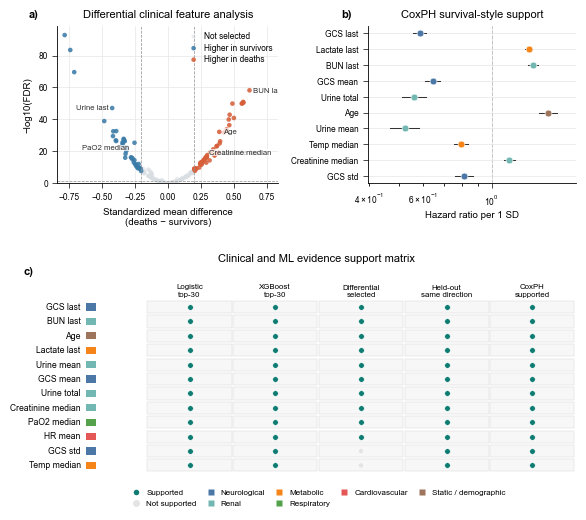

In [10]:
# ============================================================
# 10. Main Figure 3: 170 mm, panels a-c
# ============================================================

fig = plt.figure(figsize=(FIG_WIDTH_IN, 5.8))
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.0, 1.22],
    width_ratios=[1.06, 1.0],
    hspace=0.56,
    wspace=0.42,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

plot_volcano(ax_a, diff_std)
plot_cox_forest(ax_b, cox_std, matrix_df=matrix_df, max_features=10)
plot_support_matrix(ax_c, matrix_df)

add_panel_label(ax_a, "a)", x=-0.13, y=1.04)
add_panel_label(ax_b, "b)", x=-0.13, y=1.04)
add_panel_label(ax_c, "c)", x=-0.065, y=1.02)

main_outputs = save_figure(fig, "Figure3_differential_coxph_support_170mm")
plt.show()

Saved:
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Supplementary_FigureS3_differential_coxph_details_170mm.png
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Supplementary_FigureS3_differential_coxph_details_170mm.pdf
  c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Supplementary_FigureS3_differential_coxph_details_170mm.svg


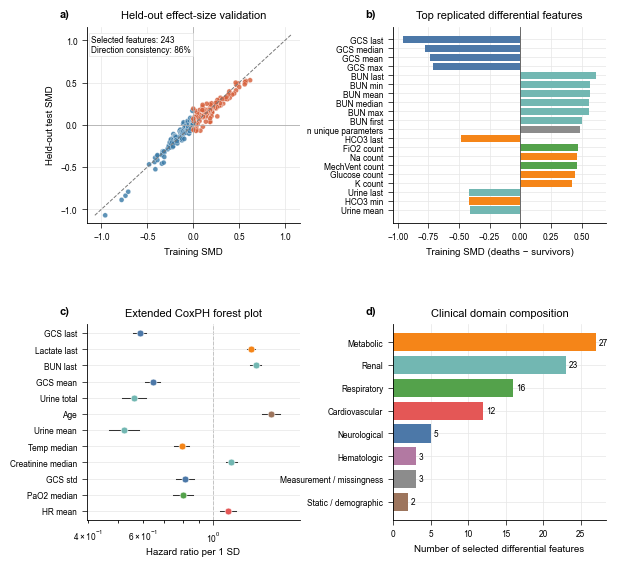

In [11]:
# ============================================================
# 11. Supplementary Figure S3: 170 mm, panels a-d only
# ============================================================

fig = plt.figure(figsize=(FIG_WIDTH_IN, 6.4))
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.52,
    wspace=0.44,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

plot_validation_scatter(ax_a, validation)
plot_top_differential(ax_b, selected_std, n=20)
plot_cox_forest(ax_c, cox_std, matrix_df=None, max_features=18)
ax_c.set_title("Extended CoxPH forest plot", fontweight="normal")
plot_domain_composition(ax_d, selected_std)

add_panel_label(ax_a, "a)", x=-0.13, y=1.04)
add_panel_label(ax_b, "b)", x=-0.13, y=1.04)
add_panel_label(ax_c, "c)", x=-0.13, y=1.04)
add_panel_label(ax_d, "d)", x=-0.13, y=1.04)

supp_outputs = save_figure(fig, "Supplementary_FigureS3_differential_coxph_details_170mm")
plt.show()

In [12]:
# ============================================================
# 12. Save manifest
# ============================================================

manifest = []

for fig_type, outputs in [("main", main_outputs), ("supplementary", supp_outputs)]:
    for ext, path in outputs.items():
        manifest.append({
            "figure_type": fig_type,
            "format": ext,
            "path": str(path),
            "width_mm": FIG_WIDTH_MM,
            "dpi_for_png": DPI if ext == "png" else "",
        })

manifest_df = pd.DataFrame(manifest)
manifest_path = FIGURE_DIR / "Figure3_output_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
display(manifest_df)

print("\nDone.")

Saved manifest: c:\Users\junse\Documents\research\IUBDC 2026\differential_analysis\figure\Figure3_output_manifest.csv


,figure_type,format,path,width_mm,dpi_for_png
0,main,png,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,600
1,main,pdf,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,
2,main,svg,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,
3,supplementary,png,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,600
4,supplementary,pdf,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,
5,supplementary,svg,c:\Users\junse\Documents\research\IUBDC 2026\d...,170,



Done.
